In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [20]:
#Select one report
file_name = "filtered_report_types_nat_hazards_nathaz_text"

# Open and read the JSON file
with open(DATA_IN_JSONS / (file_name + '.json'), 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)
#all_reports = pd.read_csv(DATA_IN_JSONS / (file_name + '.csv'), encoding='utf-8')
all_reports["reportDate"] = pd.to_datetime(all_reports["dateTime"], utc=True)

## Version 2 with extended headers
file_name = 'preproc_filtered_report_types_nat_hazards_bugfix_v220925'
#with open(DATA_IN_JSONS / (file_name + '.json'), 'r') as json_file:
#    ifrc_reports_processed = json.load(json_file)
#all_reports_v2 = pd.DataFrame(ifrc_reports_processed)
all_reports_v2 = pd.read_csv(DATA_IN_JSONS / (file_name + '.csv'), encoding='utf-8')
## Version 3
file_name = 'retest2_new_sel_filtered_report_types_nat_hazards_bugfix_v180925'
#with open(DATA_IN_JSONS / (file_name + '.json'), 'r') as json_file:
#    ifrc_reports_processed = json.load(json_file)
#all_reports_v3 = pd.DataFrame(ifrc_reports_processed)
all_reports_v3 = pd.read_csv(DATA_IN_JSONS / (file_name + '.csv'), encoding='utf-8')
# Count the len of nathaz_text
for df in [all_reports, all_reports_v2, all_reports_v3]:
    df = format_output(df, num_cols=None, list_cols=["nathaz_text"])
    df['len_nathaz_text'] = df['nathaz_text'].apply(len)
    df['reportDate'] = pd.to_datetime(df["reportDate"]).dt.date#errors="coerce"

In [21]:
#all_reports = pd.read_csv(DATA_IN_JSONS / (file_name + '.csv'), encoding='utf-8')
#all_reports["reportDate"] = pd.to_datetime(all_reports["dateTime"], utc=True)
#all_reports[all_reports['appealCode'] == 'MDRSD034']["reportDate"]

In [22]:
#all_reports["reportDate"] = pd.to_datetime(all_reports["reportDate"]).dt.date
#all_reports[all_reports['appealCode'] == 'MDRSD034']["reportDate"]

In [23]:
# Open labelled reports
df_labelled = pd.read_csv(DATA_LABELLED / 'labelled_reports_impacts_all_v160925.csv', encoding='utf-8')
df_labelled["reportDate"] = pd.to_datetime(df_labelled["reportDate"]).dt.date
#df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all.csv', encoding='utf-8')
#df_labelled["date"] = pd.to_datetime(df_labelled["reportDate"])#.dt.strftime("%d/%m/%Y")

In [49]:
# Keep only the columns we need from df_labelled
keys = df_labelled[['appealCode', 'reportDate']].drop_duplicates()

# Merge to keep only matching combos
plot_data_v1 = all_reports.merge(keys, on=['appealCode', 'reportDate'], how='inner')
plot_data_v2 = all_reports_v2.merge(keys, on=['appealCode', 'reportDate'], how='inner')
plot_data_v3 = all_reports_v3.merge(keys, on=['appealCode', 'reportDate'], how='inner')

In [50]:
#import re
#import pandas as pd
#from openpyxl.cell.cell import ILLEGAL_CHARACTERS_RE
#
## Clean the dataframe by removing illegal characters from all string cells
#def clean_illegal_chars(df):
#    return df.applymap(
#        lambda x: ILLEGAL_CHARACTERS_RE.sub("", x) if isinstance(x, str) else x
#    )
#
#plot_data_v3_clean = clean_illegal_chars(plot_data_v3)
#
#plot_data_v3_clean.to_excel(
#    DATA_IN_JSONS + "filtered_report_types_nat_hazards_nathaz_text_accuracy.xlsx",
#    index=False
#)

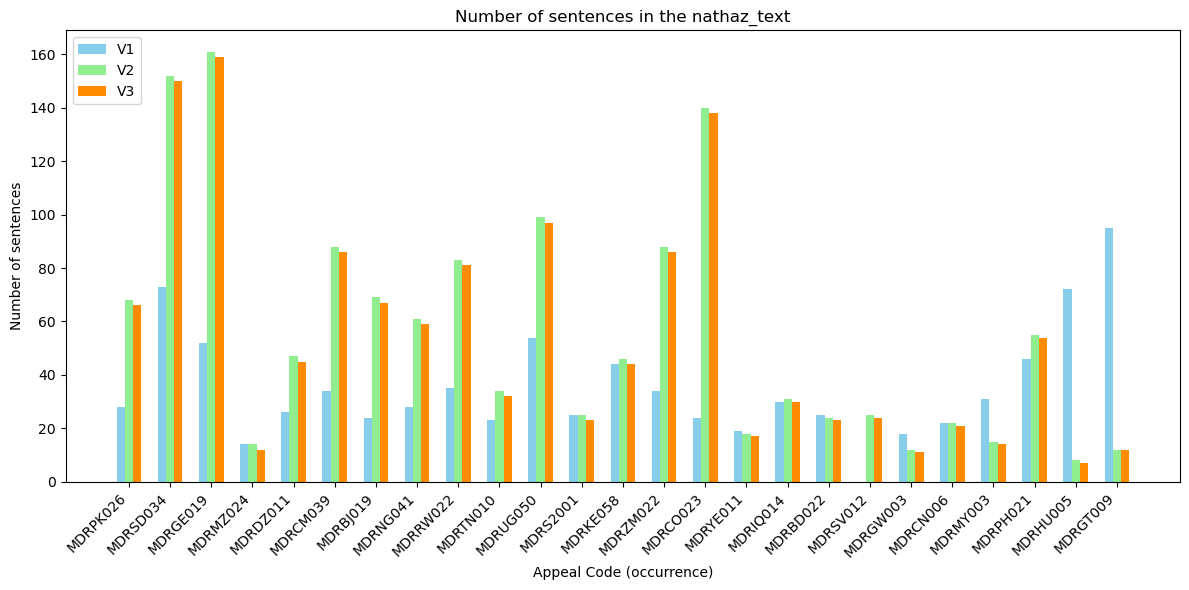

In [51]:
plot_data_v1.set_index('appealCode', inplace=True, drop=False)
plot_data_v2.set_index('appealCode', inplace=True, drop=False)
plot_data_v3.set_index('appealCode', inplace=True, drop=False)

labels = plot_data_v2.index #take v2 as one report is missing from v1

plot_data_v1 = plot_data_v1.reindex(labels) #ensure indexes are aligned
plot_data_v2 = plot_data_v2.reindex(labels)
plot_data_v3 = plot_data_v3.reindex(labels)

# Ensure both datasets are aligned in length by outer join on index
plot_data_v1 = plot_data_v1.reset_index(drop=True)
plot_data_v2 = plot_data_v2.reset_index(drop=True)
plot_data_v3 = plot_data_v3.reset_index(drop=True)

# Create a combined DataFrame so we can plot row-by-row
max_len = max(len(plot_data_v1), len(plot_data_v2), len(plot_data_v3))
plot_data_v1 = plot_data_v1.reindex(range(max_len))
plot_data_v2 = plot_data_v2.reindex(range(max_len))
plot_data_v3 = plot_data_v3.reindex(range(max_len))

# X positions for each row (not just each unique appealCode)
x = np.arange(max_len)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Bars for V1 and V2
ax.bar(x - width, plot_data_v1['len_nathaz_text'], width, label='V1', color='skyblue')
ax.bar(x , plot_data_v2['len_nathaz_text'], width, label='V2', color='lightgreen')
ax.bar(x + width, plot_data_v3['len_nathaz_text'], width, label='V3', color='darkorange')

# Use appeal codes (with index) for x-axis labels
# labels = [
#     f"{ac} ({i})" if pd.notna(ac) else ""
#     for i, ac in enumerate(plot_data_v1['appealCode'].fillna(""))
# ]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Labels and title
ax.set_ylabel("Number of sentences")
ax.set_xlabel("Appeal Code (occurrence)")
ax.set_title("Number of sentences in the nathaz_text")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [34]:
plot_data_v1

,reportName,disasterType,dateTime,date,reportLink,location,appealCode,appealType,origType,pdfDownloaded,...,disasterTypeReclassified,naturalHazard,text_processed,sentences,iso_code,hazards_found_kw,nathaz_text,secondaryDisasterType,reportDate,len_nathaz_text
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
keys[keys['appealCode'] == 'MDRGT009']

,appealCode,reportDate
502,MDRGT009,2016-11-14


In [12]:
all_reports[all_reports['appealCode'] == 'MDRGT009']

,reportName,disasterType,dateTime,date,reportLink,location,appealCode,appealType,origType,pdfDownloaded,...,disasterTypeReclassified,naturalHazard,text_processed,sentences,iso_code,hazards_found_kw,nathaz_text,secondaryDisasterType,reportDate,len_nathaz_text
1748,Guatemala - Drought (MDRGT009),Drought,2017-02-01T15:00:00+01:00,01/02/2017,https://adore.ifrc.org/Download.aspx?FileId=15...,Guatemala,MDRGT009,Operations Update,Operation Update No.3,1,...,Drought,1,P a g e 1 Operations Update N o. 3 Opera tion ...,"[P a g e 1 Operations Update N o., 3 Opera tio...",GTM,[Drought],"[Source GRC P a g e 7 Food security, nutrition...",NaN,2017-02-01,43
1793,Guatemala - Drought (MDRGT009),Drought,2016-11-14T17:00:00+01:00,14/11/2016,https://adore.ifrc.org/Download.aspx?FileId=15...,Guatemala,MDRGT009,Operations Update,Operation Update No.2,1,...,Drought,1,P a g e 1 Operation Update no. 2 Opera tion n ...,"[P a g e 1 Operation Update no., 2 Opera tion ...",GTM,[Drought],"[Food security, nutrition and livelihoods Outc...",NaN,2016-11-14,95


In [29]:
plot_data_v1

,reportName,disasterType,dateTime,date,reportLink,location,appealCode,appealType,origType,pdfDownloaded,...,disasterTypeReclassified,naturalHazard,text_processed,sentences,iso_code,hazards_found_kw,nathaz_text,secondaryDisasterType,reportDate,len_nathaz_text
0,Pakistan - Floods (MDRPK026),Flood,2025-03-28T13:01:00+01:00,28/03/2025,https://go-api.ifrc.org/api/downloadfile/88815...,Pakistan,MDRPK026,DREF Operation Final Report,MDRPK026dfr,1.0,...,Flood,1.0,DREF Final Report Pakistan Flood August 2024 N...,[DREF Final Report Pakistan Flood August 2024 ...,PAK,"[Mass movement, Flood, Storm]",[Page 1 20Description of the Event Map of targ...,NaN,2025-03-28,28.0
1,Sudan - Floods (MDRSD034),Flood,2025-03-17T12:16:00+01:00,17/03/2025,https://go-api.ifrc.org/api/downloadfile/90654...,Sudan,MDRSD034,DREF Operation Update,MDRSD034du1,1.0,...,Flood,1.0,DREF Operational Update Sudan Floods 2024 Dist...,[DREF Operational Update Sudan Floods 2024 Dis...,SDN,[Flood],[DREF Operational Update Sudan Floods 2024 Dis...,NaN,2025-03-17,73.0
2,Georgia - Snow storm (MDRGE019),Extreme Winter Condition,2025-03-16T18:16:00+01:00,16/03/2025,https://go-api.ifrc.org/api/downloadfile/90652...,Georgia,MDRGE019,DREF Operation,MDRGE019do,1.0,...,"Storm, Coldwave",1.0,DREF Operation Georgia Heavy Snowfall 2025 Vol...,[DREF Operation Georgia Heavy Snowfall 2025 Vo...,GEO,"[Mass movement, Flood, Extreme temperature, St...","[Rep., Guria, Imereti, MtskhetaMtianeti Page 1...",NaN,2025-03-16,52.0
3,Mozambique - Drought (MDRMZ024),Drought,2024-10-02T07:00:00+02:00,02/10/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Mozambique,MDRMZ024,Operations Update,MDRMZ024eu2,1.0,...,Drought,1.0,1 OPERATION UPDATE Mozambique Drought Emergenc...,[1 OPERATION UPDATE Mozambique Drought Emergen...,MOZ,"[Drought, Flood, Storm]",[SITUATION ANALYSIS Description of the crisis ...,NaN,2024-10-02,14.0
4,Algeria - Flood (MDRDZ011),Famine / Food Insecurity,2024-09-22T16:45:00+02:00,22/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Algeria,MDRDZ011,DREF Operation,MDRDZ011do,1.0,...,Flood,1.0,DREF Operation Algeria Flood 2024 Bechar Appea...,[DREF Operation Algeria Flood 2024 Bechar Appe...,DZA,[Flood],[DREF Operation Algeria Flood 2024 Bechar Appe...,NaN,2024-09-22,26.0
5,Cameroon - Floods (MDRCM039),Flood,2024-09-13T23:45:00+02:00,13/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Cameroon,MDRCM039,DREF Operation,MDRCM039do,1.0,...,Flood,1.0,DREF Operation CameroonFar North Floods Evacua...,[DREF Operation CameroonFar North Floods Evacu...,CMR,"[Drought, Flood]",[Appeal MDRCM039Country CameroonHazard FloodTy...,NaN,2024-09-13,34.0
6,Benin - Floods (MDRBJ019),Flood,2024-09-07T12:45:00+02:00,07/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Benin,MDRBJ019,DREF Operation,MDRBJ019do,1.0,...,Flood,1.0,DREF Operation BeninFlood in Lalo Field visits...,[DREF Operation BeninFlood in Lalo Field visit...,BEN,[Flood],[DREF Operation BeninFlood in Lalo Field visit...,NaN,2024-09-07,24.0
7,Nigeria - Floods (MDRNG041),Flood,2024-09-06T14:30:00+02:00,06/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Nigeria,MDRNG041,DREF Operation,MDRNG041do,1.0,...,Flood,1.0,DREF Operation Nigeria Floods DREF 2024 Flood ...,[DREF Operation Nigeria Floods DREF 2024 Flood...,NGA,[Flood],[DREF Operation Nigeria Floods DREF 2024 Flood...,NaN,2024-09-06,28.0
8,Rwanda - Floods and Landslides (MDRRW022),Flood,2024-09-05T13:45:00+02:00,05/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Rwanda,MDRRW022,DREF Operation Final Report,MDRRW022dfr,1.0,...,"Flood, Mass movement",1.0,DREF Final Report Rwanda Floods and Landslides...,[DREF Final Report Rwanda Floods and Landslide...,RWA,"[Mass movement, Flood, Storm]",[Page 1 23Description of the Event Map of the ...,NaN,2024-09-05,35.0
9,Tunisia - Forest Fires (MDRTN010),Fire,2024-09-03T14:45:00+02:00,03/09/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Tunisia,MDRTN010,DREF Operation Final Report,MDRTN010fr,1.0,...,Wi

In [57]:
appeal = "MDRNG041"
print(plot_data_v1[plot_data_v1['appealCode'] == appeal]["reportDate"])
plot_data_v1[plot_data_v1['appealCode'] == appeal]["nathaz_text"].values[0]

7    2024-09-06
Name: reportDate, dtype: object


['DREF Operation Nigeria Floods DREF 2024 Flood cuts o major access road linking Kano to Maiduguri in Katagum community, Bauchi state Appeal MDRNG041Country NigeriaHazard FloodType of DREF Response Crisis Category YellowEvent Onset SuddenDREF Allocation CHF 231,293 Glide Number People Aected 50,000 peoplePeople Targeted 9,000 people Operation Start Date 03092024Operation Timeframe 4 monthsOperation End Date 31012025DREF Published 06092024 Targeted AreasBauchi, Kebbi, Sokoto, Zamfara Page 1 17Description of the Event Date of event 13082024 Nigeria Flood Forecast 2024 What happened, where and when?',
 'From August 8 to August 13, 2024, continuous heavy rainfall triggered severe ooding across Nigeria, leading to widespread devastation and displacement in states such as Bauchi, Sokoto, and Zamfara.',
 'In Bauchi State, over 1,000 homes were destroyed, particularly impacting the Giade, Shira, and Katagum local government areas.',
 'Earlier, on July 17, 2024, ooding in Sokoto State displaced

In [58]:
print(plot_data_v3[plot_data_v3['appealCode'] == appeal]["reportDate"])
plot_data_v3[plot_data_v3['appealCode'] == appeal]["nathaz_text"].values[0]

7    2024-09-06
Name: reportDate, dtype: object


['DREF Operation Nigeria Floods DREF 2024 Flood cuts off major access road linking Kano to Maiduguri in Katagum community, Bauchi state Appeal: MDRNG041 Country: Nigeria Hazard: Flood Type of DREF: Response Crisis Category: Yellow Event Onset: Sudden DREF Allocation: CHF 231,293 Glide Number: - People Affected: 50,000 people People Targeted: 9,000 people Operation Start Date: 03-09-2024 Operation Timeframe: 4 months Operation End Date: 31-01-2025 DREF Published: 06-09-2024 Targeted Areas: Bauchi, Kebbi, Sokoto, Zamfara Page 1 / 17 Description of the Event Date of event 13-08-2024 Nigeria Flood Forecast 2024 What happened, where and when?',
 'From August 8 to August 13, 2024, continuous heavy rainfall triggered severe flooding across Nigeria, leading to widespread devastation and displacement in states such as Bauchi, Sokoto, and Zamfara.',
 'In Bauchi State, over 1,000 homes were destroyed, particularly impacting the Giade, Shira, and Katagum local government areas.',
 'Earlier, on Jul